# Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

# Loading the Dataset from sciketLearn

In [ ]:
# Using California Housing dataset (real-world data)
from sklearn.datasets import fetch_california_housing

# Load the data
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target  # Median house value in $100,000s

# Looking at the dataset

In [ ]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df
print("\nDataset Info:")
df.info()
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (20640, 9)

First 5 rows:

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Basic Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
# column descriptions
column_descriptions = {
    "MedInc": "Median income in the district (in tens of thousands of US dollars). Example: 3.5 means $35,000.",
    "HouseAge": "Median age of houses in the district (in years).",
    "AveRooms": "Average number of rooms per household.",
    "AveBedrms": "Average number of bedrooms per household.",
    "Population": "Total population of the district.",
    "AveOccup": "Average number of people per household.",
    "Latitude": "Latitude coordinate of the district (geographic location).",
    "Longitude": "Longitude coordinate of the district (geographic location).",
    "MedHouseVal": "Median house value for the district (in hundreds of thousands of US dollars). Example: 2.5 means $250,000."
}

#  Exploratory Data Analysis (EDA)

In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


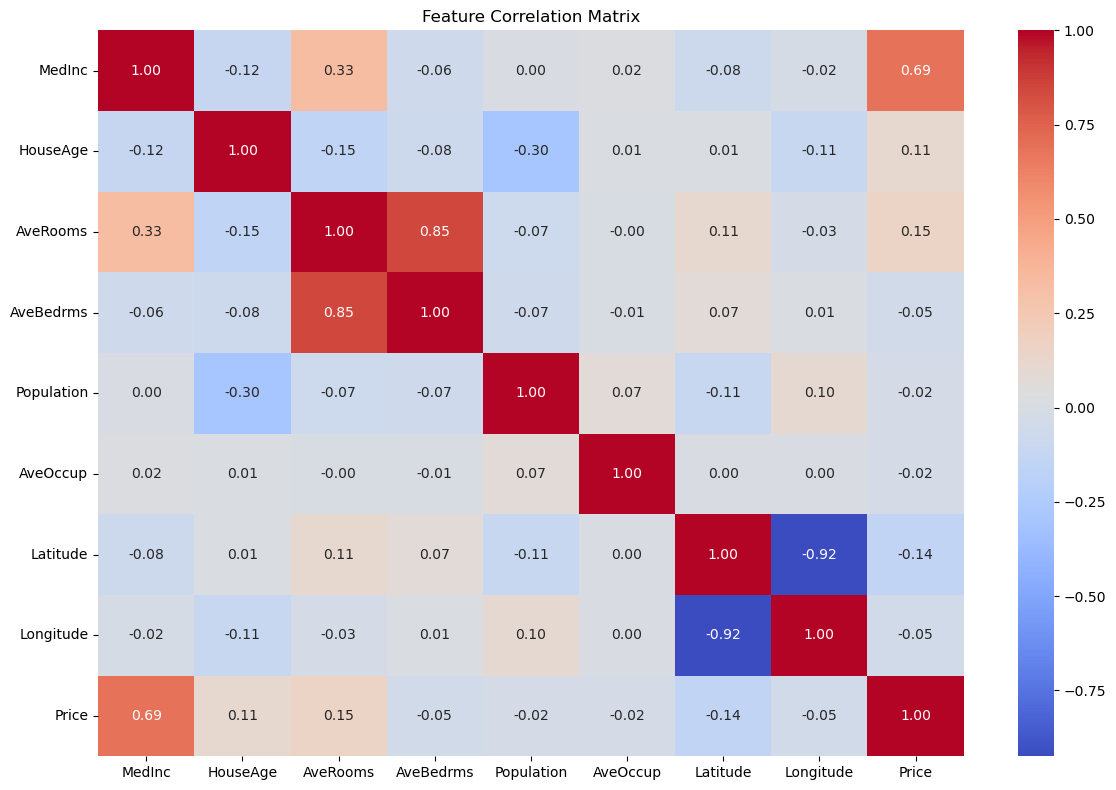

In [ ]:
# Correlation analysis
# 1.0 = Perfect positive relationship (as one goes up, other goes up)
# -1.0 = Perfect negative relationship (as one goes up, other goes down)
# 0 = No relationship
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

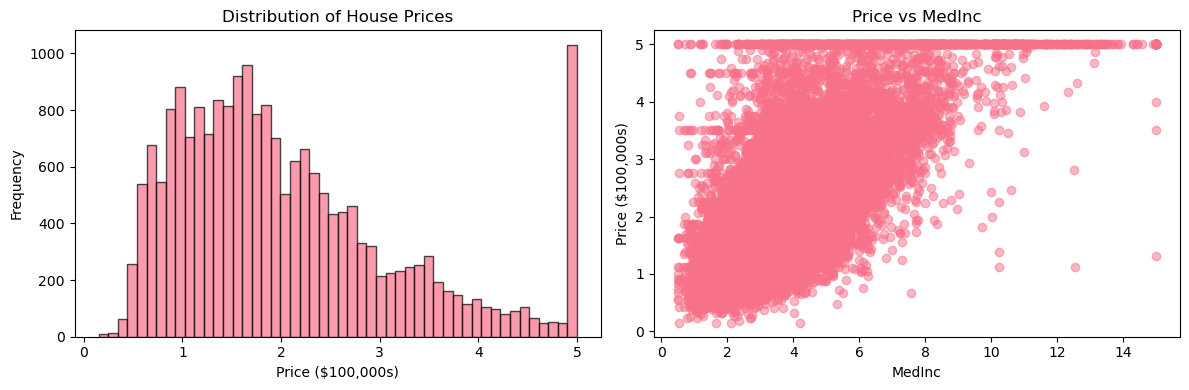

In [ ]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of House Prices')
axes[0].set_xlabel('Price ($100,000s)')
axes[0].set_ylabel('Frequency')

# Relationship with most correlated feature
most_correlated = correlation_matrix['Price'].abs().sort_values(ascending=False).index[1]
axes[1].scatter(df[most_correlated], df['Price'], alpha=0.5)
axes[1].set_title(f'Price vs {most_correlated}')
axes[1].set_xlabel(most_correlated)
axes[1].set_ylabel('Price ($100,000s)')
plt.tight_layout()
plt.show()

# Code to Extract Numerical Insights from These Plots

In [ ]:
# Get numerical values that the plots show visually
print("="*60)
print("NUMERICAL INSIGHTS FROM VISUALIZATIONS")
print("="*60)

# Histogram insights
print("\nPRICE DISTRIBUTION INSIGHTS:")
print(f"Mean Price: ${df['Price'].mean() * 100000:,.2f}")
print(f"Median Price: ${df['Price'].median() * 100000:,.2f}")
print(f"Mode Price (approx): ${df['Price'].mode()[0] * 100000:,.2f}")
print(f"Price Std Dev: ${df['Price'].std() * 100000:,.2f}")
print(f"Skewness: {df['Price'].skew():.3f} (0=normal, >0=right-skewed)")
print(f"Price Range: ${df['Price'].min()*100000:,.0f} - ${df['Price'].max()*100000:,.0f}")

# Scatter plot insights
print(f"\nRELATIONSHIP WITH {most_correlated}:")
print(f"Correlation Coefficient: {correlation_matrix.loc[most_correlated, 'Price']:.3f}")
print(f"R-squared: {correlation_matrix.loc[most_correlated, 'Price']**2:.3f}")
print(f"Interpretation: {most_correlated} explains {correlation_matrix.loc[most_correlated, 'Price']**2*100:.1f}% of price variation")

# Simple linear regression on just this feature
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(df[most_correlated], df['Price'])
print(f"\nSIMPLE LINEAR MODEL (Price ~ {most_correlated}):")
print(f"For each 1 unit increase in {most_correlated}:")
print(f"  Price increases by ${slope * 100000:,.2f}")
print(f"Statistical significance: p={p_value:.6f}")

NUMERICAL INSIGHTS FROM VISUALIZATIONS

PRICE DISTRIBUTION INSIGHTS:
Mean Price: $206,855.82
Median Price: $179,700.00
Mode Price (approx): $500,001.00
Price Std Dev: $115,395.62
Skewness: 0.978 (0=normal, >0=right-skewed)
Price Range: $14,999 - $500,001

RELATIONSHIP WITH MedInc:
Correlation Coefficient: 0.688
R-squared: 0.473
Interpretation: MedInc explains 47.3% of price variation

SIMPLE LINEAR MODEL (Price ~ MedInc):
For each 1 unit increase in MedInc:
  Price increases by $41,793.85
Statistical significance: p=0.000000


# Feature Selection and Engineering

In [ ]:
# Let's create some additional features for better learning
df['Rooms_per_Household'] = df['AveRooms'] / df['AveOccup']
df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']
df['Population_per_Household'] = df['Population'] / df['AveOccup']

# Select features for modeling
feature_columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                  'Population', 'AveOccup', 'Latitude', 'Longitude',
                  'Rooms_per_Household', 'Bedrooms_per_Room',
                  'Population_per_Household']

X = df[feature_columns]
y = df['Price']

print("Selected features:", feature_columns)
print("\nFeature matrix shape:", X.shape)

Selected features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Rooms_per_Household', 'Bedrooms_per_Room', 'Population_per_Household']

Feature matrix shape: (20640, 11)


# Train-Test Split

In [ ]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 16512 samples
Test set size: 4128 samples


# Feature Scaling

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns)

# Train Linear Regression Model

In [ ]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Get model coefficients
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Model Coefficients (Feature Importance):")
print(coefficients)
print(f"\nIntercept: {model.intercept_:.4f}")

Model Coefficients (Feature Importance):
                     Feature  Coefficient
6                   Latitude    -0.884011
7                  Longitude    -0.827089
0                     MedInc     0.781719
8        Rooms_per_Household     0.374271
10  Population_per_Household     0.286658
4                 Population    -0.236612
9          Bedrooms_per_Room     0.232474
3                  AveBedrms    -0.202792
1                   HouseAge     0.140920
2                   AveRooms    -0.033698
5                   AveOccup     0.002455

Intercept: 2.0719


# Make Predictions

In [ ]:
# Predict on both training and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# display models prediction values

In [ ]:
# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual_Price': y_test.values * 100000,
    'Predicted_Price': y_test_pred * 100000,
    'Difference': (y_test_pred - y_test.values) * 100000,
    'Absolute_Error': abs(y_test_pred - y_test.values) * 100000
})

# Add percentage error
comparison_df['Percentage_Error'] = abs((comparison_df['Difference'] / comparison_df['Actual_Price']) * 100)

# Format as currency for display
pd.options.display.float_format = '${:,.2f}'.format

print("All Test Set Predictions:")
print(comparison_df.head(20))  # Shows first 20 houses

# Reset display format
pd.reset_option('display.float_format')

All Test Set Predictions:
    Actual_Price  Predicted_Price   Difference  Absolute_Error  \
0     $47,700.00       $49,903.04    $2,203.04       $2,203.04   
1     $45,800.00      $174,868.69  $129,068.69     $129,068.69   
2    $500,001.00      $346,176.94 $-153,824.06     $153,824.06   
3    $218,600.00      $262,337.29   $43,737.29      $43,737.29   
4    $278,000.00      $265,874.92  $-12,125.08      $12,125.08   
5    $158,700.00      $202,278.18   $43,578.18      $43,578.18   
6    $198,200.00      $254,281.99   $56,081.99      $56,081.99   
7    $157,500.00      $190,853.64   $33,353.64      $33,353.64   
8    $340,000.00      $294,602.74  $-45,397.26      $45,397.26   
9    $446,600.00      $393,921.59  $-52,678.41      $52,678.41   
10   $123,200.00       $85,499.87  $-37,700.13      $37,700.13   
11   $253,900.00      $193,282.95  $-60,617.05      $60,617.05   
12   $215,100.00      $124,482.48  $-90,617.52      $90,617.52   
13   $220,500.00      $183,793.70  $-36,706.30    

In [ ]:
# Combine original features with predictionsu
detailed_predictions = X_test.copy()
detailed_predictions['Actual_Price'] = y_test.values
detailed_predictions['Predicted_Price'] = y_test_pred
detailed_predictions['Difference'] = y_test_pred - y_test.values
detailed_predictions['Percent_Error'] = abs((detailed_predictions['Difference'] / detailed_predictions['Actual_Price']) * 100)

# Convert prices to dollars for display
detailed_predictions['Actual_Price'] = detailed_predictions['Actual_Price'] * 100000
detailed_predictions['Predicted_Price'] = detailed_predictions['Predicted_Price'] * 100000
detailed_predictions['Difference'] = detailed_predictions['Difference'] * 100000

print("\nDetailed Predictions with Features:")
print(detailed_predictions[['MedInc', 'HouseAge', 'Actual_Price', 'Predicted_Price', 'Difference', 'Percent_Error']].head(10))


Detailed Predictions with Features:
       MedInc  HouseAge  Actual_Price  Predicted_Price     Difference  \
20046  1.6812      25.0       47700.0     49903.042593    2203.042593   
3024   2.5313      30.0       45800.0    174868.694724  129068.694724   
15663  3.4801      52.0      500001.0    346176.937855 -153824.062145   
20484  5.7376      17.0      218600.0    262337.288272   43737.288272   
9814   3.7250      34.0      278000.0    265874.921704  -12125.078296   
13311  4.7147      12.0      158700.0    202278.183507   43578.183507   
7113   5.0839      36.0      198200.0    254281.992869   56081.992869   
7668   3.6908      38.0      157500.0    190853.641812   33353.641812   
18246  4.8036       4.0      340000.0    294602.739077  -45397.260923   
5723   8.1132      45.0      446600.0    393921.592812  -52678.407188   

       Percent_Error  
20046       4.618538  
3024      281.809377  
15663      30.764751  
20484      20.007909  
9814        4.361539  
13311      27.459473 

 # Model Evaluation

In [ ]:
def evaluate_model(y_true, y_pred, dataset_name):
    """Calculate and print evaluation metrics"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{dataset_name} Performance:")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Evaluate on both sets
train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")


Training Performance:
MSE:  0.4482
RMSE: 0.6695
MAE:  0.4828
R²:   0.6647

Test Performance:
MSE:  0.4540
RMSE: 0.6738
MAE:  0.4874
R²:   0.6535


#  Visualize Results

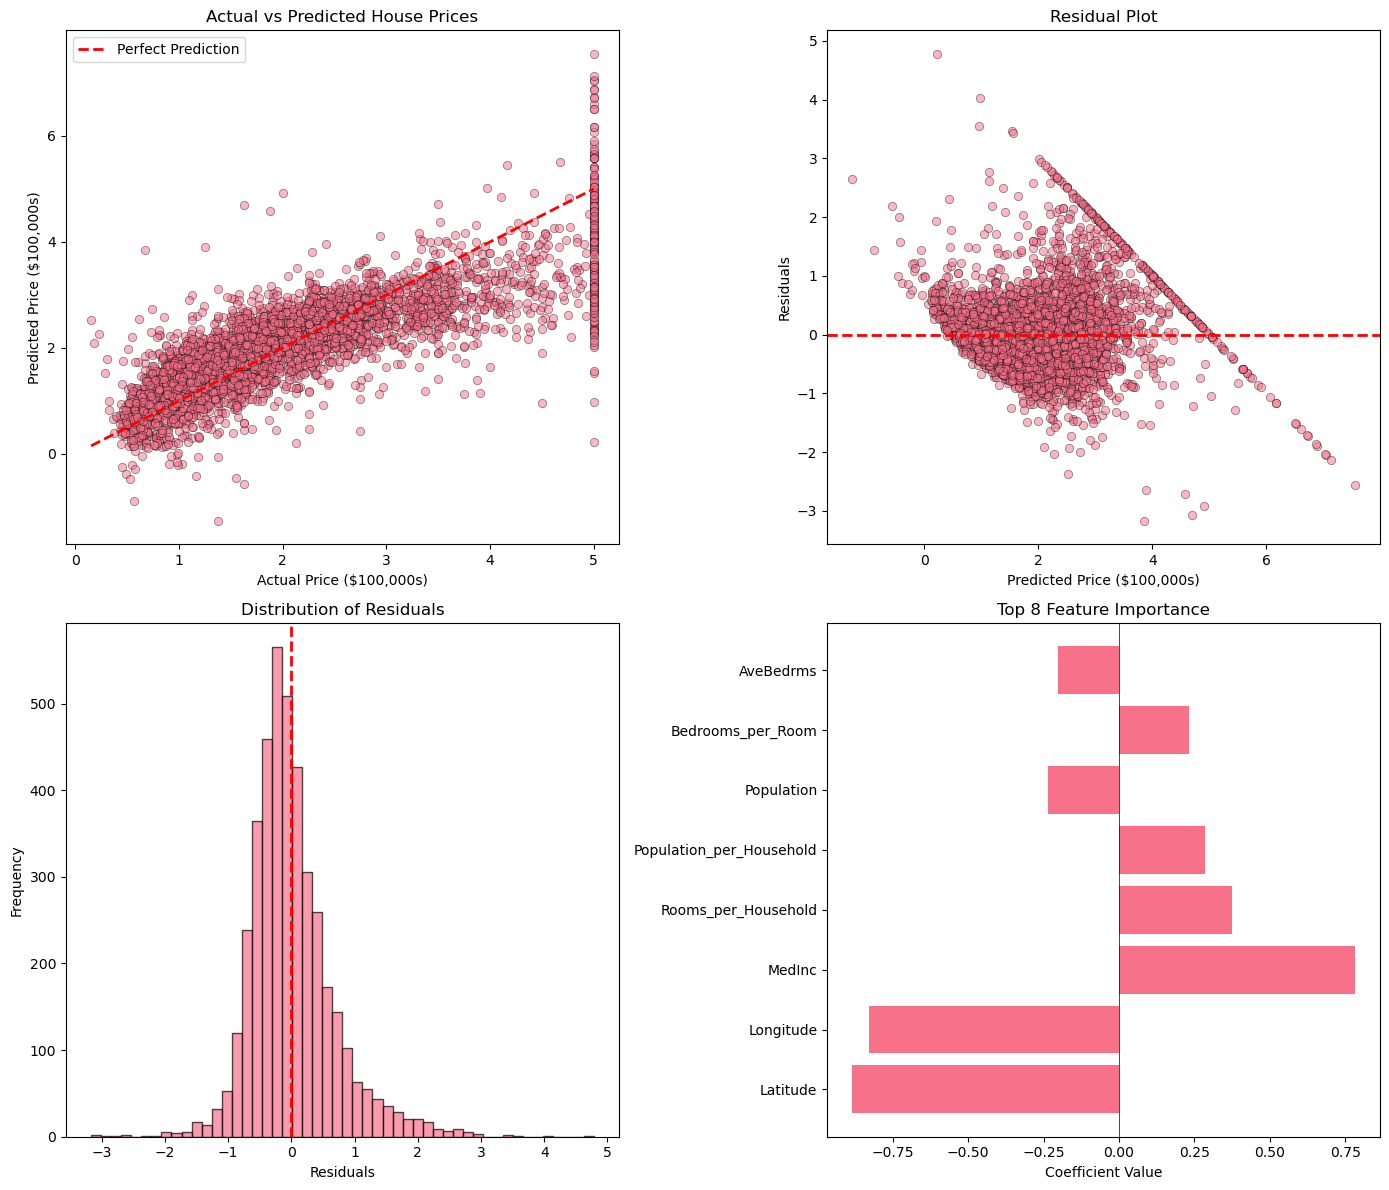

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Actual vs Predicted Plot
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Price ($100,000s)')
axes[0, 0].set_ylabel('Predicted Price ($100,000s)')
axes[0, 0].set_title('Actual vs Predicted House Prices')
axes[0, 0].legend()

# 2. Residual Plot
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Price ($100,000s)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')

# 3. Residual Distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)

# 4. Feature Importance (Coefficients)
coeff_plot = coefficients.head(8)
axes[1, 1].barh(coeff_plot['Feature'], coeff_plot['Coefficient'])
axes[1, 1].set_xlabel('Coefficient Value')
axes[1, 1].set_title('Top 8 Feature Importance')
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)


plt.tight_layout()
plt.show()

# Cross-Validation


Cross-Validation Results:
Individual fold R² scores: [0.66364065 0.65524892 0.68845433 0.65820533 0.63173573]
Mean R²: 0.6595 (+/- 0.0363)


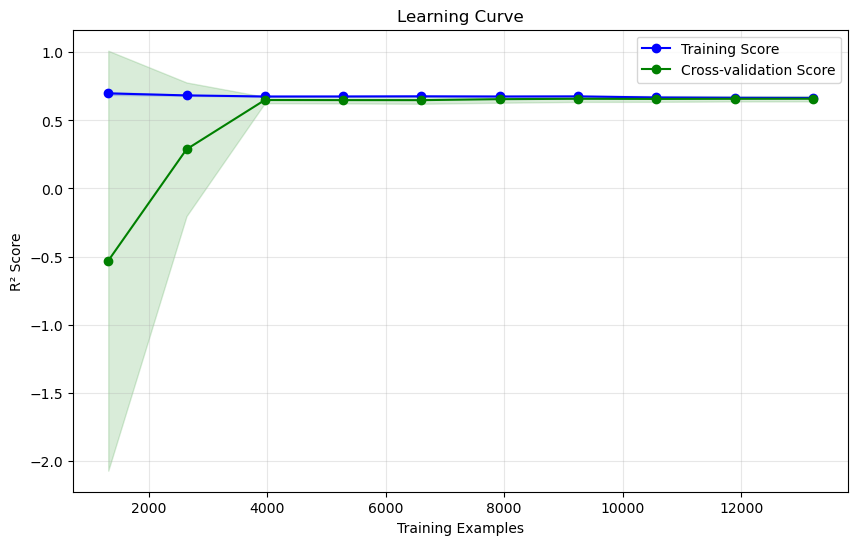

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train,
                           cv=kf, scoring='r2')

print("\nCross-Validation Results:")
print(f"Individual fold R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Learning curve analysis
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_scaled, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation Score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Model Interpretation

In [ ]:
# Calculate feature contributions for a sample prediction
sample_idx = 1
sample_features = X_test_scaled.iloc[sample_idx:sample_idx+1]
actual_price = y_test.iloc[sample_idx]
predicted_price = model.predict(sample_features)[0]

# Calculate contribution of each feature
contributions = pd.DataFrame({
    'Feature': feature_columns,
    'Contribution': model.coef_ * sample_features.values[0]
}).sort_values('Contribution', key=abs, ascending=False)

print(f"\nSample Prediction Analysis (House #{sample_idx}):")
print(f"Actual Price: ${actual_price * 100000:.2f}")
print(f"Predicted Price: ${predicted_price * 100000:.2f}")
print(f"Difference: ${(predicted_price - actual_price) * 100000:.2f}")
print("\nTop Feature Contributions:")
print(contributions.head(8))


Sample Prediction Analysis (House #1):
Actual Price: $45800.00
Predicted Price: $174868.69
Difference: $129068.69

Top Feature Contributions:
                     Feature  Contribution
0                     MedInc     -0.553972
6                   Latitude      0.208176
9          Bedrooms_per_Room      0.096107
10  Population_per_Household      0.063217
7                  Longitude     -0.050431
3                  AveBedrms     -0.045318
8        Rooms_per_Household     -0.033269
4                 Population     -0.028831


# Summary

In [ ]:
print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
print(f"Model Type: Linear Regression")
print(f"Number of Features: {len(feature_columns)}")
print(f"Training R² Score: {train_metrics['R2']:.4f}")
print(f"Test R² Score: {test_metrics['R2']:.4f}")
print(f"Cross-validation R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("\nMost Important Features:")
for idx, row in coefficients.head(3).iterrows():
    print(f"  - {row['Feature']}: {row['Coefficient']:.4f}")


MODEL SUMMARY
Model Type: Linear Regression
Number of Features: 11
Training R² Score: 0.6647
Test R² Score: 0.6535
Cross-validation R²: 0.6595 (+/- 0.0363)

Most Important Features:
  - Latitude: -0.8840
  - Longitude: -0.8271
  - MedInc: 0.7817
